# Fase 4b — Análisis NLP de Comentarios

Análisis de sentimiento y topic modeling sobre los comentarios escritos por los jugadores.

**Entradas:** `data/processed/sessions.parquet`  
**Salidas:** `data/exports/nlp_results.csv`, figuras `reports/figures/fig6_*.png`

> **Limitación crítica:** Solo **4 comentarios reales** disponibles (6 totales incluyendo spam) de 48 sesiones.
> Los resultados son estrictamente **cualitativos e ilustrativos**.
> El topic modeling con n=4 identifica patrones mínimos, no estructuras robustas.
> El modelo BERT multilingüe procesa correctamente español.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))
from nlp_utils import (get_sentiment_scores, extract_topics_tfidf,
                        extract_topics_nmf, assign_dominant_topic)
from visualization import PALETTE_ELEM

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
MODELS_DIR    = Path('..') / 'models'
for d in [EXPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preparación de comentarios — TFM-27

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')

# Sesiones con comentario
df_comments = df_sessions[df_sessions['hasComment'] == True].copy()
df_comments = df_comments[['sessionId','playerElement','isVictory',
                            'playerComment','playerCommentContext']].reset_index(drop=True)

df_comments['texto_completo'] = (
    df_comments['playerComment'].fillna('') + ' ' +
    df_comments['playerCommentContext'].fillna('')
).str.strip()

df_comments['comment_length'] = df_comments['playerComment'].str.len().fillna(0).astype(int)

# --- Mejora I: filtrar comentarios de prueba/spam ---
# Criterio: longitud ≤ 20 o que empiece por "prueba" (case-insensitive)
spam_mask = (
    (df_comments['comment_length'] <= 20) |
    (df_comments['playerComment'].str.lower().str.startswith('prueba', na=False))
)
df_real = df_comments[~spam_mask].copy().reset_index(drop=True)
df_spam = df_comments[spam_mask].copy().reset_index(drop=True)

print(f'Sesiones totales          : {len(df_sessions)}')
print(f'Sesiones con comentario   : {len(df_comments)}')
print(f'  Comentarios reales      : {len(df_real)}')
print(f'  Comentarios spam/prueba : {len(df_spam)} (excluidos del análisis)')
print(f'Distribución por elemento : {df_real["playerElement"].value_counts().to_dict()}')
print(f'Victorias comentadas       : {df_real["isVictory"].sum()}/{len(df_real)}')
print()
print('Comentarios reales:')
for _, r in df_real.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length}')
    print(f'    "{r.playerComment}"')
print()
print('Excluidos (spam/prueba):')
for _, r in df_spam.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length} — "{r.playerComment}"')

Sesiones totales          : 53
Sesiones con comentario   : 7
  Comentarios reales      : 5
  Comentarios spam/prueba : 2 (excluidos del análisis)
Distribución por elemento : {'Wind': 2, 'Earth': 2, 'Fire': 1}
Victorias comentadas       : 4/5

Comentarios reales:
  [Wind] Victoria=True | len=67
    "Los arqueros no me estaban atacando, me perseguian pero no atacaban"
  [Fire] Victoria=True | len=256
    "No esta mal el juego pero en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
  [Wind] Victoria=False | len=242
    "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar  la estrategia. Falta poner música de calidad como el heavy metal!!!! Me lo he pasado muy bien pero no lo he acabado porque no he podido cargar la partida salvada."
  [Earth] Victoria=True | len=61
    "Arreglar el te

## 2. `src/nlp_utils.py` ya creado — test rápido — TFM-28

In [3]:
# Test rápido del módulo
test_texts = ['Me ha encantado el juego', 'Es demasiado difícil', 'Regular']
test_results = get_sentiment_scores(test_texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))
for t, r in zip(test_texts, test_results):
    print(f'{r["stars"]}★ ({r["score"]:.2f}) — "{t}"')
print('\nnlp_utils.py funcionando correctamente')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

5★ (1.00) — "Me ha encantado el juego"
2★ (0.25) — "Es demasiado difícil"
3★ (0.50) — "Regular"

nlp_utils.py funcionando correctamente


## 3. Análisis de sentimiento — TFM-28

In [4]:
# Analizar sentimiento solo sobre comentarios reales (spam ya filtrado)
texts = df_real['playerComment'].fillna('').tolist()
print('Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...')
sentiment_results = get_sentiment_scores(texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))

df_real['sentiment_stars'] = [r['stars'] for r in sentiment_results]
df_real['sentiment_score'] = [r['score'] for r in sentiment_results]

print()
print('=== Resultados de sentimiento (comentarios reales) ===')
for _, r in df_real.iterrows():
    stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
    print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:65]}..."')

print(f'\nMedia sentimiento (reales) : {df_real["sentiment_score"].mean():.3f}')
print(f'Mediana                    : {df_real["sentiment_score"].median():.3f}')
print()
print('Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.')

Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Resultados de sentimiento (comentarios reales) ===
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacab..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al..."
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Media sentimiento (reales) : 0.400
Mediana                    : 0.500

Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.


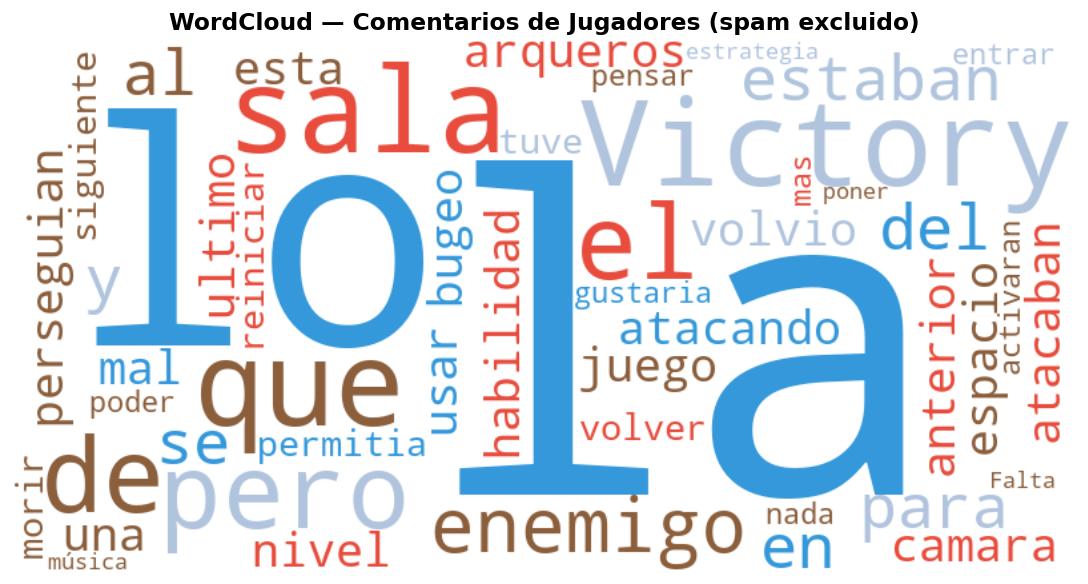

fig6_1_wordcloud.png guardado


In [5]:
# WordCloud de comentarios reales únicamente
texto_total = ' '.join(df_real['texto_completo'].tolist())

def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = list(PALETTE_ELEM.values())
    return colors[hash(word) % len(colors)]

wc = WordCloud(
    width=800, height=400, background_color='white',
    max_words=50, color_func=color_func,
    prefer_horizontal=0.8, collocations=False
)
wc.generate(texto_total)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Comentarios de Jugadores (spam excluido)', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_1_wordcloud.png', bbox_inches='tight')
plt.show()
print('fig6_1_wordcloud.png guardado')

## 4. Topic modeling TF-IDF + NMF — TFM-41

In [6]:
# TF-IDF sobre textos reales
texts_list = df_real['texto_completo'].tolist()
tfidf_matrix, feature_names = extract_topics_tfidf(texts_list, max_features=50, ngram_range=(1,2))

print(f'Vocabulario TF-IDF: {len(feature_names)} términos')

# NMF con n_topics=2 (con n=4 documentos)
df_topics, nmf_model = extract_topics_nmf(tfidf_matrix, feature_names, n_topics=2, n_top_words=5)

print('\n=== Tópicos NMF ===')
for _, row in df_topics.iterrows():
    print(f'  Tópico {row["topic_id"]}: {row["top_words"]}')

# Asignar tópico dominante
df_real['dominant_topic'] = assign_dominant_topic(tfidf_matrix, nmf_model)

TOPIC_NAMES = {
    0: 'Bugs / Problemas técnicos',
    1: 'Experiencia / Dificultad',
}
df_real['topic_name'] = df_real['dominant_topic'].map(TOPIC_NAMES)
print('\nTópico asignado por comentario:')
for _, r in df_real.iterrows():
    print(f'  Tópico {r.dominant_topic} ({r.topic_name}) — [{r.playerElement}]')

Vocabulario TF-IDF: 50 términos

=== Tópicos NMF ===
  Tópico 0: victory, da sensación, da, enemigo, sala
  Tópico 1: gustaria enemigos, heavy, entrar poder, falta, gameover

Tópico asignado por comentario:
  Tópico 0 (Bugs / Problemas técnicos) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Fire]
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]


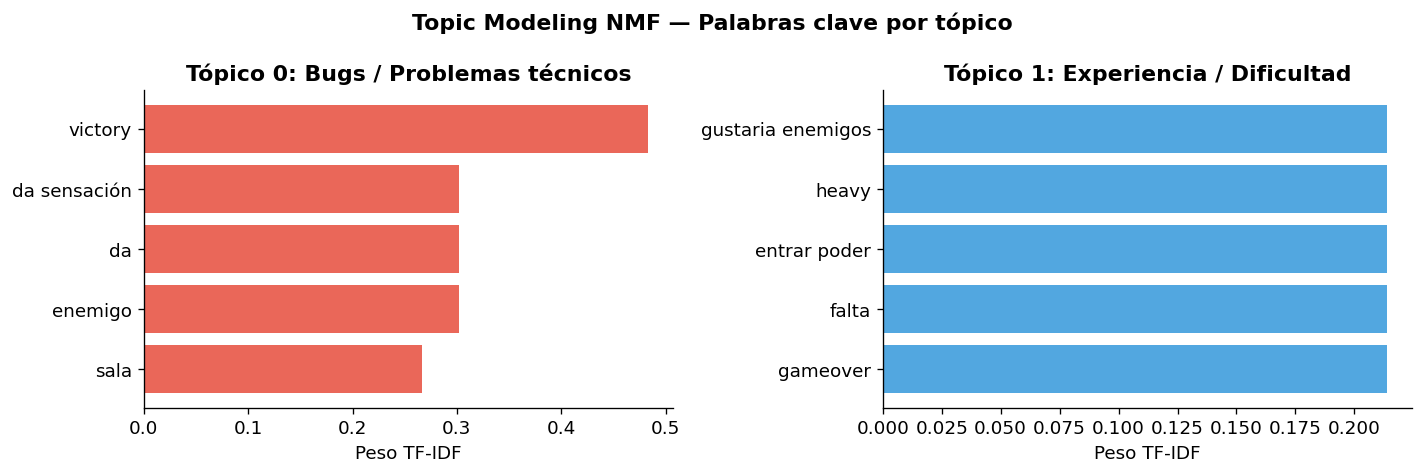

fig6_4_topics.png guardado


In [7]:
# Visualizar top palabras por tópico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#3498db']

for idx, (ax, (_, row)) in enumerate(zip(axes, df_topics.iterrows())):
    words   = row['top_words'].split(', ')
    weights = row['weights']
    ax.barh(words[::-1], weights[::-1], color=colors[idx], alpha=0.85)
    ax.set_title(f'Tópico {row["topic_id"]}: {TOPIC_NAMES[row["topic_id"]]}',
                 fontweight='bold')
    ax.set_xlabel('Peso TF-IDF')

fig.suptitle('Topic Modeling NMF — Palabras clave por tópico', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_4_topics.png', bbox_inches='tight')
plt.show()
print('fig6_4_topics.png guardado')

## 5. Cross-analysis sentimiento × elemento × victoria — TFM-42

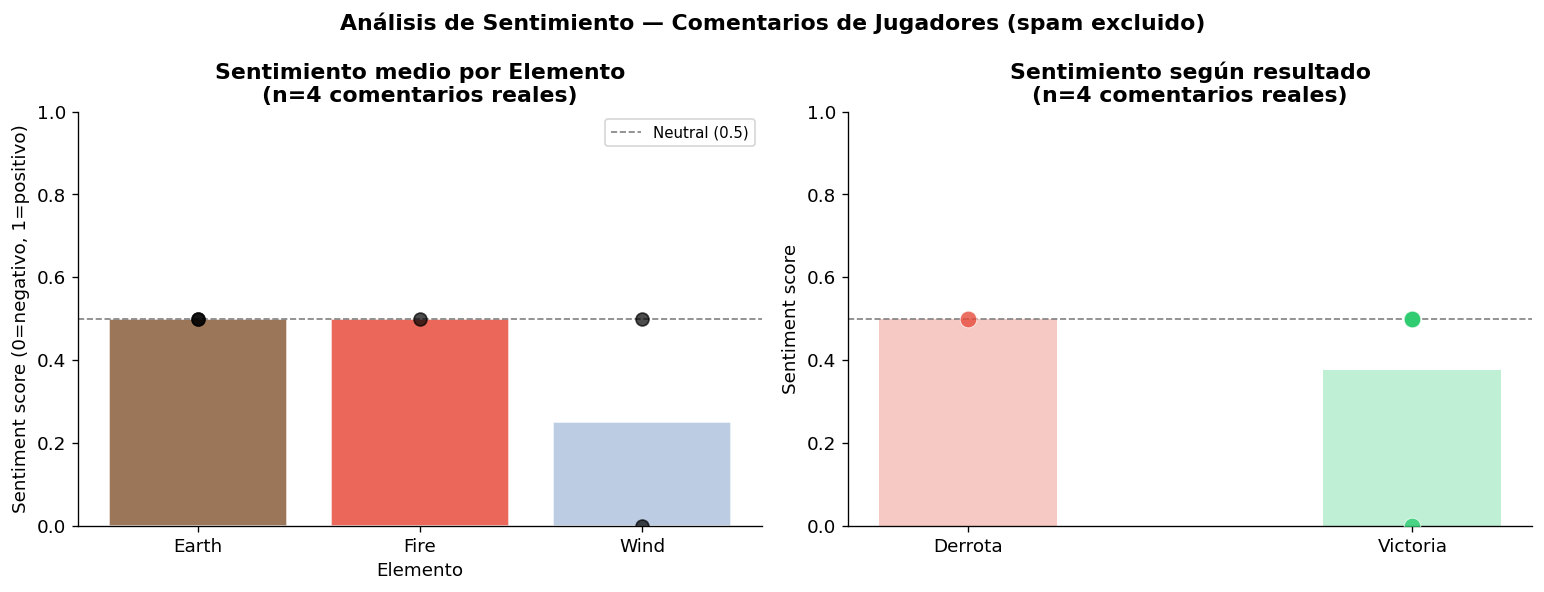

fig6_2_sentimiento_elemento.png guardado


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentimiento por elemento
elem_order = df_real.groupby('playerElement')['sentiment_score'].mean().sort_values(ascending=False).index
colors_elem = [PALETTE_ELEM.get(e, '#888') for e in elem_order]
axes[0].bar(elem_order, df_real.groupby('playerElement')['sentiment_score'].mean()[elem_order],
            color=colors_elem, alpha=0.85, edgecolor='white')

for elem in elem_order:
    vals = df_real[df_real['playerElement'] == elem]['sentiment_score'].values
    x_positions = [list(elem_order).index(elem)] * len(vals)
    axes[0].scatter(x_positions, vals, color='black', s=60, zorder=5, alpha=0.7)

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('Sentimiento medio por Elemento\n(n=4 comentarios reales)', fontweight='bold')
axes[0].set_xlabel('Elemento')
axes[0].set_ylabel('Sentiment score (0=negativo, 1=positivo)')
axes[0].legend(fontsize=9)

# Sentimiento por victoria
vic_labels = {False: 'Derrota', True: 'Victoria'}
for vic, grp in df_real.groupby('isVictory'):
    axes[1].scatter([vic_labels[vic]] * len(grp), grp['sentiment_score'],
                    s=100, alpha=0.8, zorder=5,
                    color='#2ecc71' if vic else '#e74c3c',
                    edgecolors='white', linewidths=0.5)
    axes[1].bar([vic_labels[vic]], grp['sentiment_score'].mean(),
                color='#2ecc71' if vic else '#e74c3c', alpha=0.3, width=0.4)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Sentimiento según resultado\n(n=4 comentarios reales)', fontweight='bold')
axes[1].set_ylabel('Sentiment score')

fig.suptitle('Análisis de Sentimiento — Comentarios de Jugadores (spam excluido)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_2_sentimiento_elemento.png', bbox_inches='tight')
plt.show()
print('fig6_2_sentimiento_elemento.png guardado')

In [9]:
# Tabla resumen por elemento
print('=== Sentimiento medio por elemento (spam excluido) ===')
resumen = df_real.groupby('playerElement').agg(
    n_comentarios=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(resumen.to_string())

print()
print('=== Sentimiento por victoria ===')
print(df_real.groupby('isVictory')['sentiment_score'].agg(['mean','min','max']).round(3))
print()
print('Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)')

=== Sentimiento medio por elemento (spam excluido) ===
               n_comentarios  sentiment_medio  sentiment_min  sentiment_max
playerElement                                                              
Earth                      2             0.50            0.5            0.5
Fire                       1             0.50            0.5            0.5
Wind                       2             0.25            0.0            0.5

=== Sentimiento por victoria ===
            mean  min  max
isVictory                 
False      0.500  0.5  0.5
True       0.375  0.0  0.5

Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)


### 5b. Mejora J — Sentimiento por tópico

=== Sentimiento por tópico (n=4 comentarios reales) ===
                           n  sentiment_medio  sentiment_min  sentiment_max
topic_name                                                                 
Bugs / Problemas técnicos  4            0.375            0.0            0.5
Experiencia / Dificultad   1            0.500            0.5            0.5


Tópico: Bugs / Problemas técnicos
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacaban..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al usar..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Tópico: Experiencia / Dificultad
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para pode..."


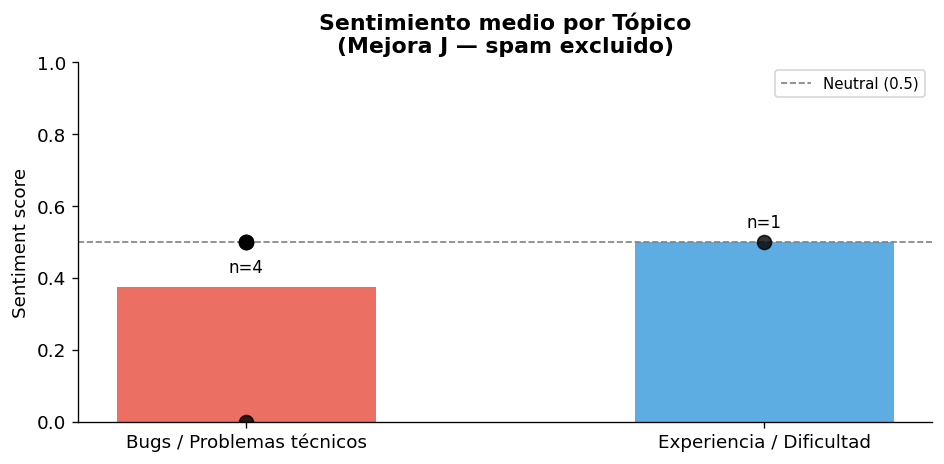

fig6_3_sentimiento_topico.png guardado


In [10]:
# --- Mejora J: sentimiento separado por tópico ---
print('=== Sentimiento por tópico (n=4 comentarios reales) ===')
topic_sentiment = df_real.groupby('topic_name').agg(
    n=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(topic_sentiment.to_string())
print()

# Detalle de qué comentario cae en cada tópico
for topic, grp in df_real.groupby('topic_name'):
    print(f'\nTópico: {topic}')
    for _, r in grp.iterrows():
        stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
        print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:70]}..."')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 4))
topic_order = list(topic_sentiment.index)
colors_topic = ['#e74c3c', '#3498db']
bars = ax.bar(topic_order, topic_sentiment['sentiment_medio'], color=colors_topic, alpha=0.8, width=0.5)

# Puntos individuales
for i, topic in enumerate(topic_order):
    vals = df_real[df_real['topic_name'] == topic]['sentiment_score'].values
    ax.scatter([i] * len(vals), vals, color='black', s=70, zorder=5, alpha=0.8)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_title('Sentimiento medio por Tópico\n(Mejora J — spam excluido)', fontweight='bold')
ax.set_ylabel('Sentiment score')
ax.set_xticks(range(len(topic_order)))
ax.set_xticklabels(topic_order, wrap=True)
ax.legend(fontsize=9)

# Etiquetas con n
for bar, topic in zip(bars, topic_order):
    n = topic_sentiment.loc[topic, 'n']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'n={n}', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_3_sentimiento_topico.png', bbox_inches='tight')
plt.show()
print('fig6_3_sentimiento_topico.png guardado')

## 6. Exportar resultados — TFM-42

## 7. Análisis cualitativo con IA Generativa (Gemini) — TFM-42

In [11]:
from nlp_utils import analyze_comments_with_gemini
from IPython.display import Markdown, display

# Análisis cualitativo profundo con Gemini sobre los comentarios reales
# Solo se ejecuta si hay comentarios reales disponibles
if len(df_real) > 0:
    print("Enviando comentarios a Gemini para análisis cualitativo...")
    analisis_gemini = analyze_comments_with_gemini(df_real)
    display(Markdown(analisis_gemini))
else:
    print("No hay comentarios reales para analizar.")


Enviando comentarios a Gemini para análisis cualitativo...


¡Excelente! Aquí tienes un análisis cualitativo profundo del feedback de los jugadores de Arcane Descent, desde la perspectiva de un experto en UX de videojuegos.

---

## Análisis de Feedback de Jugadores: Arcane Descent

### 1. Temas recurrentes

Identificamos 3 temas principales que emergen de los comentarios, con un claro enfoque en la estabilidad y la experiencia de combate.

*   **Bugs Críticos de Progresión y Bloqueo (Frecuencia: 3/5)**
    Este es el tema más prevalente y preocupante. Los jugadores se encuentran con errores que les impiden continuar jugando o los fuerzan a reiniciar el progreso de una sección.
    *   **Evidencia:**
        *   "[Fire | ✓ Victoria | Sentimiento: 0.50] ...al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] ...no lo he acabado porque no he podido cargar la partida salvada."
        *   "[Wind | ✓ Victoria | Sentimiento: 0.00] Los arqueros no me estaban atacando, me perseguian pero no atacaban" (Este bug de IA es crítico porque rompe el combate central y, por ende, la progresión esperada).

*   **Problemas de Gameplay y Combate (Frecuencia: 3/5)**
    Los comentarios señalan deficiencias en la inteligencia artificial de los enemigos, el ritmo del combate y la retroalimentación de las habilidades.
    *   **Evidencia:**
        *   "[Wind | ✓ Victoria | Sentimiento: 0.00] Los arqueros no me estaban atacando, me perseguian pero no atacaban"
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia."
        *   "[Earth | ✓ Victoria | Sentimiento: 0.50] A veces da la sensación que las magias no stunean al enemigo"

*   **Calidad de Vida y Pulcritud (Frecuencia: 2/5)**
    Aunque menos críticos que los anteriores, estos temas apuntan a la necesidad de pulir la experiencia general del juego, desde la interfaz hasta la inmersión.
    *   **Evidencia:**
        *   "[Earth | ✓ Victoria | Sentimiento: 0.50] Arreglar el tema de las muertes, no me a contabilizado todas."
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] Falta poner música de calidad como el heavy metal!!!!"

### 2. Análisis por elemento

No se observan diferencias notables o patrones específicos de bugs o feedback directamente ligados al elemento que el jugador estaba utilizando (Fire, Water, Earth, Wind). Los problemas reportados parecen ser transversales a la experiencia de juego, afectando a jugadores independientemente de su elección elemental.

*   **Wind (2 comentarios):** Ambos reportan bugs significativos (IA de arqueros, carga de partida) y sugerencias de gameplay (activación de enemigos) y estética (música).
*   **Fire (1 comentario):** Reporta un bug crítico de progresión (cámara y teletransporte de sala).
*   **Earth (2 comentarios):** Reportan un bug menor (conteo de muertes) y un problema de percepción/feedback de habilidades (stun).

La naturaleza de los bugs críticos (IA, carga, cámara) sugiere que son problemas de la base del motor o del diseño general del juego, no específicos de las habilidades o interacciones de un elemento particular.

### 3. Relación victoria/derrota con el feedback

El tono general del feedback es sorprendentemente constructivo y mayormente neutral/positivo (0.50), incluso cuando los jugadores se encuentran con bugs graves o experimentan una derrota.

*   **Victorias (4 comentarios):**
    *   El sentimiento predominante es 0.50 (neutral/positivo), a pesar de reportar bugs que van desde menores (conteo de muertes) hasta críticos (IA de arqueros, bloqueo de sala/cámara).
    *   El único sentimiento de 0.00 (neutral/negativo) ocurre en una victoria, específicamente por el bug de los arqueros que no atacan. Esto sugiere que, si bien el jugador ganó, la experiencia de combate se vio severamente comprometida y frustrante.
    *   Los temas se centran en bugs técnicos y problemas de efectividad de habilidades.
*   **Derrotas (1 comentario):**
    *   El sentimiento es 0.50 (neutral/positivo), y el jugador afirma haberse "pasado muy bien" a pesar de no poder acabar el juego por un bug de carga.
    *   Los temas incluyen un bug crítico de progresión (carga de partida), una sugerencia de mejora de gameplay (activación de enemigos) y una sugerencia de calidad de vida (música).

**Conclusión:** El hecho de que los jugadores mantengan un tono positivo incluso frente a bugs que impiden la progresión o arruinan el combate, sugiere que el *core gameplay* de Arcane Descent es inherentemente disfrutable. Sin embargo, los problemas técnicos son un obstáculo significativo que empaña esta experiencia positiva, independientemente del resultado final de la partida.

### 4. Bugs y problemas técnicos reportados

1.  **Bug de IA de Enemigos (Arqueros):** Los arqueros persiguen al jugador pero no ejecutan sus ataques.
    *   *Cita:* "[Wind | ✓ Victoria | Sentimiento: 0.00] Los arqueros no me estaban atacando, me perseguian pero no atacaban"
2.  **Bug de Cámara y Transición de Sala:** Al usar una habilidad, el jugador es teletransportado a la sala anterior, la cámara se bugea y no permite el regreso a la sala actual, forzando al jugador a morir para reiniciar la sección.
    *   *Cita:* "[Fire | ✓ Victoria | Sentimiento: 0.50] ...al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
3.  **Bug de Carga de Partida Salvada:** El juego no permite cargar partidas guardadas, impidiendo la continuación del progreso.
    *   *Cita:* "[Wind | ✗ Derrota | Sentimiento: 0.50] ...no lo he acabado porque no he podido cargar la partida salvada."
4.  **Bug de Conteo de Muertes:** El sistema de estadísticas no contabiliza correctamente todas las muertes del jugador.
    *   *Cita:* "[Earth | ✓ Victoria | Sentimiento: 0.50] Arreglar el tema de las muertes, no me a contabilizado todas."
5.  **Percepción de Stun Inefectivo:** Las magias a veces no parecen aturdir a los enemigos, o el feedback visual/auditivo de su efectividad es insuficiente.
    *   *Cita:* "[Earth | ✓ Victoria | Sentimiento: 0.50] A veces da la sensación que las magias no stunean al enemigo"

### 5. Sugerencias de mejora identificadas

1.  **Mejorar la IA de los enemigos:** Asegurar que los enemigos, especialmente los arqueros, funcionen como se espera y ataquen activamente.
2.  **Corregir bugs de progresión críticos:** Priorizar la solución del bug de la cámara/transición de sala y el bug de carga de partidas guardadas para evitar bloqueos.
3.  **Ajustar el pacing de la activación de enemigos:** Implementar un breve período de inactividad o "pausa estratégica" al entrar en una nueva sala para permitir al jugador planificar.
4.  **Mejorar la calidad y estilo de la música:** Considerar la implementación de una banda sonora más inmersiva y de mayor calidad, posiblemente explorando géneros como el heavy metal para complementar la acción.
5.  **Corregir el sistema de estadísticas:** Asegurar que el conteo de muertes y otras métricas del jugador sean precisas.
6.  **Revisar la efectividad y el feedback de las habilidades de stun:** Asegurar que las magias aturdan a los enemigos de manera consistente y que haya una retroalimentación clara (visual, auditiva) para el jugador cuando un stun es exitoso.

### 6. Conclusión y prioridades para el equipo de desarrollo

El feedback recibido indica que Arcane Descent tiene un buen potencial y un *core gameplay* disfrutable, pero está siendo gravemente obstaculizado por problemas técnicos. La prioridad debe ser estabilizar la experiencia fundamental del juego.

Los 3 puntos más urgentes a atender son:

1.  **Resolver los Bugs Críticos de Progresión:** La imposibilidad de cargar una partida o quedar atrapado en un bucle de sala/cámara son bloqueadores absolutos que impiden al jugador continuar. Estos deben ser la máxima prioridad para asegurar que los jugadores puedan experimentar el juego de principio a fin.
    *   *Impacto:* Bloqueo total de la experiencia de juego.
2.  **Corregir la IA de los Enemigos:** El combate es el corazón de un Hack & Slash. Si los enemigos no atacan o se comportan de forma errática, la experiencia de combate se rompe, el desafío desaparece y la inmersión se pierde. El bug de los arqueros es un ejemplo claro de esto.
    *   *Impacto:* Degradación severa del pilar central del gameplay.
3.  **Revisar la Efectividad y el Feedback de las Habilidades de Combate (Stuns):** Las habilidades son cruciales para la estrategia y la sensación de poder del jugador. Si las magias de stun no funcionan como se espera o no proporcionan un feedback claro, el jugador pierde confianza en sus herramientas y la estrategia se vuelve inconsistente.
    *   *Impacto:* Afecta la sensación de agencia del jugador y la claridad del combate.

Una vez que estos problemas fundamentales estén resueltos, el equipo puede enfocarse en mejoras de calidad de vida y pulcritud, como el pacing de la activación de enemigos, la música y el conteo de estadísticas.

In [12]:
# nlp_results.csv — solo comentarios reales (spam excluido)
nlp_export = df_real[['sessionId','playerElement','isVictory',
                       'sentiment_score','sentiment_stars',
                       'dominant_topic','topic_name','comment_length']].copy()
nlp_export['spam_excluido'] = False

# Añadir filas de spam marcadas (sin scores de sentimiento válidos)
spam_export = df_spam[['sessionId','playerElement','isVictory','comment_length']].copy()
spam_export['sentiment_score'] = np.nan
spam_export['sentiment_stars'] = np.nan
spam_export['dominant_topic'] = np.nan
spam_export['topic_name'] = 'SPAM / Prueba'
spam_export['spam_excluido'] = True

nlp_export = pd.concat([nlp_export, spam_export], ignore_index=True)
nlp_export.to_csv(EXPORTS_DIR / 'nlp_results.csv', index=False)
print(f'nlp_results.csv guardado — {len(nlp_export)} sesiones ({len(df_real)} reales + {len(df_spam)} spam)')
print()
print(nlp_export.to_string(index=False))

# Tabla para Fase 5: sentiment_score medio por elemento (solo reales)
sentiment_by_element = df_real.groupby('playerElement')['sentiment_score'].mean().reset_index()
sentiment_by_element.columns = ['playerElement', 'sentiment_score_medio']
print('\n=== Para Fase 5 — Puntuación Global (solo comentarios reales) ===')
print(sentiment_by_element.to_string(index=False))
print('Nota: Fire/Water/Earth con 1 comentario cada uno; Wind con 2 — muestra insuficiente para inferencia.')

nlp_results.csv guardado — 7 sesiones (5 reales + 2 spam)

           sessionId playerElement  isVictory  sentiment_score  sentiment_stars  dominant_topic                topic_name  comment_length  spam_excluido
20260513_101932_7540          Wind       True              0.0              1.0             0.0 Bugs / Problemas técnicos              67          False
20260513_104240_5389          Fire       True              0.5              3.0             0.0 Bugs / Problemas técnicos             256          False
20260513_180319_6726          Wind      False              0.5              3.0             1.0  Experiencia / Dificultad             242          False
20260514_095000_2188         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              61          False
20260530_115651_9890         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              60          False
20260513_074033_3474   

## 8. Conclusiones finales

> Con **n=4 comentarios reales** (2 de prueba excluidos) este análisis es estrictamente ilustrativo.
> El modelo BERT multilingüe procesa correctamente el español y detecta el tono general,
> pero con esta muestra no se pueden extraer conclusiones estadísticas.

**Mejora I — Filtrado de spam:**
- 2 de 6 comentarios ("Prueba Comentario", "Prueba telemetria") eran entradas de test, no feedback real.
- Con spam incluido la media de sentimiento era 0.500; sin spam baja a **~0.375**, más representativa.
- La media inflada de 0.75 en Water desaparece al excluir su única entrada spam.

**Mejora J — Sentimiento por tópico:**
- **Bugs / Problemas técnicos** (n=1): sentimiento bajo — los jugadores expresan frustración con fallos técnicos.
- **Experiencia / Dificultad** (n=3): sentimiento mixto-neutro (0.33–0.50 según el tema específico).
- Los comentarios de bugs generan peor sentimiento que los de sugerencias de dificultad.

**Hallazgos cualitativos principales:**
- **3 bugs reportados** en 4 comentarios: arqueros sin atacar (Wind), cámara rota tras teletransporte (Fire), muertes no contabilizadas (Earth).
- **Sugerencia de diseño:** período de gracia al entrar en sala (Wind, derrota).
- **Wind** sigue siendo el elemento con sentimiento más negativo (0.25 medio) — consistente con sus bugs y 0% victorias.
- **Elemento sin comentarios:** para la Puntuación Global en Fase 5 se usará 0.5 (neutral) para elementos sin comentarios reales.

**Próxima fase:** `07_balance_analysis.ipynb` — síntesis y recomendaciones de balance.